# BC05 — Industrialisation : rendre le modèle utilisable par tous (notebook de démonstration)

## De quoi parle-t-on ?

BC03 a entraîné un modèle (`modeles/pipeline_ml.pkl`). Mais un modèle qui ne « vit » que dans un
notebook n'est utile à personne d'autre que la personne qui l'a codé. **Industrialiser**, c'est
l'envelopper dans une interface simple, standardisée et accessible :

- une **API** (un guichet automatique pour le modèle, que d'autres programmes peuvent interroger) ;
- un **tableau de bord web** (un formulaire, pour une personne qui ne code pas) ;
- un **conteneur Docker** (une « boîte » qui fait tourner l'API à l'identique sur n'importe quelle
  machine).

## Pourquoi ce bloc ?

Le référentiel RNCP demande de savoir **exposer un modèle** et **automatiser** son usage. Ici on ne
lance pas de serveur dans le notebook (ce sont des processus longue durée) : on **reproduit la
logique exacte de l'API**, on la teste, et on explique l'API, le dashboard et Docker.

## Comment suivre ce notebook

1. **Charger** le modèle de production de BC03.
2. **Reproduire `/predict`** sans serveur, sur un exemple concret.
3. Faire **varier la saison** pour voir le modèle réagir.
4. **Appeler l'API pour de vrai** (sans lancer de serveur, avec un client de test).
5. **Le tableau de bord** Streamlit (présentation).
6. **Docker** (présentation).

Comme les autres notebooks, celui-ci utilise le **vrai code du bloc**
([`prediction.py`](prediction.py), [`api.py`](api.py), [`run.py`](run.py)).

## 0. Préparation

In [1]:
import sys
from pathlib import Path

_racine = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
_bloc = _racine / "blocs" / "bc05_industrialisation"
for _p in (str(_racine), str(_bloc)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")

from commun.config import REPERTOIRE_MODELES, ESPECES
print("Racine du projet :", _racine)

Racine du projet : C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc


## 1. Charger le modèle de production

C'est le fichier `modeles/pipeline_ml.pkl` produit par BC03 (le XGBoost retenu). L'API le charge
**exactement de la même façon** à son démarrage (`joblib.load`, voir [`api.py`](api.py)).

In [2]:
modele = joblib.load(REPERTOIRE_MODELES / "pipeline_ml.pkl")
print("Type            :", type(modele).__name__)
print("Étapes          :", [nom for nom, _ in modele.steps])
print("Colonnes vues à l'entraînement :")
print(" ", list(modele.feature_names_in_))

Type            : Pipeline
Étapes          : ['normalisation', 'modele']
Colonnes vues à l'entraînement :
  ['annee', 'semaine', 'lat_discrete', 'lon_discrete', 'temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']


**Ce que c'est.** Un `Pipeline` scikit-learn : une **normalisation** (`StandardScaler`) suivie du
**XGBoost**. Le pipeline « se souvient » des 11 colonnes vues à l'entraînement — l'API devra lui
fournir exactement celles-là, dans le bon ordre.

## 2. Reproduire `/predict` sans lancer de serveur

Toute la logique de prédiction est dans un seul module, [`prediction.py`](prediction.py), **partagé**
entre l'API et la démo de `run.py` (pour qu'un changement ne soit pas fait dans l'un et oublié dans
l'autre). La fonction `predire` :

1. transforme la requête (espèce, position, météo) en **features** (`construire_donnees_features`) —
   au passage, le `jour_annee` devient un numéro de **semaine** ;
2. **aligne les colonnes** sur celles attendues par le modèle (`aligner_colonnes`) ;
3. calcule la **probabilité** (`predict_proba`) et un **niveau de confiance**
   (`calculer_confiance` : BASSE < 0,60 · MOYENNE 0,60–0,75 · HAUTE > 0,75).

In [3]:
from prediction import predire

exemple_requete = {
    "espece": "hirondelle_rustique",
    "latitude": 50.5,
    "longitude": 2.75,
    "meteo": {
        "temperature_max": 18.5,
        "temperature_min": 12.3,
        "precipitation_sum": 2.1,
        "vent_max": 15.0,
        "humidite_moyenne": 65.0,
        "jour_annee": 105,   # mi-avril
    },
}

probabilite, confiance = predire(
    modele, exemple_requete["latitude"], exemple_requete["longitude"], exemple_requete["meteo"]
)

print("Requête (équivalent d'un POST /predict) :")
for cle, valeur in exemple_requete.items():
    print(f"   {cle}: {valeur}")
print("\nRéponse du modèle :")
print(f"   probabilité de présence : {probabilite*100:.1f} %")
print(f"   confiance               : {confiance}")

Requête (équivalent d'un POST /predict) :
   espece: hirondelle_rustique
   latitude: 50.5
   longitude: 2.75
   meteo: {'temperature_max': 18.5, 'temperature_min': 12.3, 'precipitation_sum': 2.1, 'vent_max': 15.0, 'humidite_moyenne': 65.0, 'jour_annee': 105}

Réponse du modèle :
   probabilité de présence : 3.9 %
   confiance               : BASSE


**Ce que ça donne.** Une probabilité et un niveau de confiance — exactement ce que renverra
l'endpoint `/predict`. La probabilité est faible ici : mi-avril, au centre de la région, sans autre
signal fort, le modèle reste prudent (cohérent avec le déséquilibre 98/2 de BC03).

## 3. Le modèle réagit-il à la saison ?

BC02 et BC03 ont montré que **la période de l'année** est le facteur le plus important. Vérifions-le
« côté utilisateur » : on garde tout fixe (position, météo) et on fait **varier le jour de l'année**
sur 12 mois. Si le modèle a bien appris, la probabilité doit **remonter au printemps**.

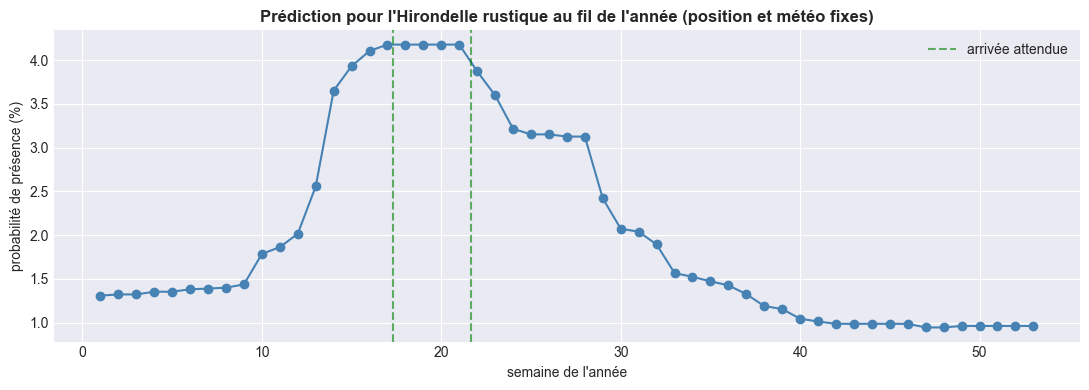

In [4]:
jours = list(range(1, 366, 7))
meteo_fixe = dict(exemple_requete["meteo"])
probas = []
for j in jours:
    meteo_fixe["jour_annee"] = j
    p, _ = predire(modele, exemple_requete["latitude"], exemple_requete["longitude"], meteo_fixe)
    probas.append(p * 100)

semaines = [(j - 1) // 7 + 1 for j in jours]
plt.figure(figsize=(11, 4))
plt.plot(semaines, probas, marker="o", color="steelblue")
for m in ESPECES["hirondelle_rustique"]["mois_arrivee"]:
    plt.axvline(m * 52 / 12, color="green", linestyle="--", alpha=0.6,
                label="arrivée attendue" if m == ESPECES["hirondelle_rustique"]["mois_arrivee"][0] else None)
plt.xlabel("semaine de l'année")
plt.ylabel("probabilité de présence (%)")
plt.title("Prédiction pour l'Hirondelle rustique au fil de l'année (position et météo fixes)",
          fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

**Ce que ça nous apprend.** La courbe **monte au printemps / début d'été** et retombe en hiver,
autour des mois d'arrivée attendus. Le modèle exposé par l'API reproduit donc bien le signal
saisonnier vu tout au long du projet. *(Petite limite : `predire` utilise l'**année en cours** pour
la feature `annee` ; le modèle extrapole donc légèrement au-delà de 2024.)*

## 4. L'API, pour de vrai — sans lancer de serveur

L'API est construite avec **FastAPI** ([`api.py`](api.py)) et expose **3 points d'entrée** :

| Requête | Rôle |
|---|---|
| `GET /health` | vérifie que l'API et le modèle sont chargés (une « prise de pouls ») |
| `GET /species` | liste les espèces et leur calendrier de migration |
| `POST /predict` | reçoit espèce + position + météo, renvoie une probabilité |

On peut interroger l'API **sans serveur** grâce à un **client de test** (`TestClient`) : il envoie
de vraies requêtes HTTP à l'application, en mémoire.

In [5]:
from fastapi.testclient import TestClient
from api import app

client = TestClient(app)
client.get("/health").json()

2026-09-08 15:21:38 | INFO     | api:<module>:121 - Modele charge : C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc\modeles\pipeline_ml.pkl


{'statut': 'OK',
 'modele_charge': True,
 'version': '1.0.0',
 'timestamp': '2026-09-08T15:21:38.691153'}

In [6]:
client.get("/species").json()

{'hirondelle_rustique': {'nom_francais': 'Hirondelle rustique',
  'nom_scientifique': 'Hirundo rustica',
  'mois_arrivee': [4, 5],
  'mois_depart': [9, 10]},
 'cigogne_blanche': {'nom_francais': 'Cigogne blanche',
  'nom_scientifique': 'Ciconia ciconia',
  'mois_arrivee': [3, 4],
  'mois_depart': [8, 9]},
 'martinet_noir': {'nom_francais': 'Martinet noir',
  'nom_scientifique': 'Apus apus',
  'mois_arrivee': [5, 6],
  'mois_depart': [8, 9]},
 'bergeronnette_printaniere': {'nom_francais': 'Bergeronnette printaniere',
  'nom_scientifique': 'Motacilla alba',
  'mois_arrivee': [3, 4],
  'mois_depart': [10, 11]}}

In [7]:
# POST /predict avec une requête valide
requete = {
    "espece": "hirondelle_rustique",
    "latitude": 50.5, "longitude": 2.75,
    "meteo": {"temperature_max": 20.0, "temperature_min": 12.0, "precipitation_sum": 1.0,
              "vent_max": 12.0, "humidite_moyenne": 60.0, "jour_annee": 120},
}
reponse = client.post("/predict", json=requete)
print("statut HTTP :", reponse.status_code)
reponse.json()

statut HTTP : 200


{'espece': 'hirondelle_rustique',
 'probabilite_presence': 0.04211973771452904,
 'confiance': 'BASSE',
 'date_prediction': '2026-09-08T15:21:38.742644',
 'modele_utilise': 'XGBoost'}

In [8]:
# POST /predict avec une latitude impossible (99°) : l'API doit refuser AVANT d'appeler le modèle
requete_invalide = dict(requete, latitude=99.0)
reponse = client.post("/predict", json=requete_invalide)
print("statut HTTP :", reponse.status_code, "(422 = donnée rejetée par la validation)")
print(reponse.json()["detail"][0]["msg"])

statut HTTP : 422 (422 = donnée rejetée par la validation)
Input should be less than or equal to 51.5


**Ce que ça nous apprend.** Chaque requête est **validée automatiquement** (librairie *Pydantic*,
schémas `ObservationMeteo` / `DemandePredicton` dans [`api.py`](api.py)) : une latitude de 99°, une
température de 300°C ou une humidité négative sont rejetées avec un **code 422** et un message clair,
**sans jamais atteindre le modèle**. On ne fait pas de prédiction sur des données absurdes.

## 5. Le tableau de bord Streamlit (présentation)

Une API reste un outil de développeur (elle ne renvoie que du texte structuré). Le projet ajoute un
**tableau de bord web** ([`dashboard.py`](dashboard.py), *Streamlit*) pour un utilisateur final,
avec **4 onglets** :

1. **Prédiction** — un formulaire (menus, curseurs) pour choisir espèce / date / météo / position
   et obtenir une probabilité, sans écrire une ligne de code ;
2. **Statistiques** — reprend les graphiques de BC02 et le comparatif de BC03 ;
3. **Données** — parcourt un extrait des observations nettoyées ;
4. **Documentation** — explique le projet en langage courant.

Le dashboard **appelle l'API** en arrière-plan (`requests.post(f"{API_URL}/predict", ...)`) : la
preuve qu'on peut réutiliser le même service (l'API) pour plusieurs usages. On le lance dans un
terminal, l'API tournant à côté :

```bash
python -m uvicorn api:app --reload            # terminal 1 : l'API
python -m streamlit run dashboard.py          # terminal 2 : le dashboard -> http://localhost:8501
```

## 6. Docker (présentation)

Problème classique : *« ça marche sur mon ordinateur, pas sur le tien »* (versions de Python
différentes, librairies manquantes…). **Docker** empaquette le programme **et tout son
environnement** (Python, librairies, modèle) dans une « boîte » standardisée — le *conteneur* — qui
tourne à l'identique partout.

Le [`Dockerfile`](Dockerfile) de ce dossier décrit cette boîte pour l'API : image de base
(`python:3.11-slim`), installation des dépendances (`requirements.txt` dédié, sans TensorFlow ni
Jupyter), copie du code + du modèle `pipeline_ml.pkl`, et la commande qui démarre `uvicorn` sur le
port 8000. Un *healthcheck* interroge `/health` toutes les 30 s.

```bash
docker build -f blocs/bc05_industrialisation/Dockerfile -t oiseaux-migrateurs-api .
docker run -p 8000:8000 oiseaux-migrateurs-api
```

## 6b. La chaîne complète : `docker compose`

Le `Dockerfile` ci-dessus n'empaquette que l'**API**. Pour une démonstration réaliste, le projet
fournit un `docker-compose.yml` (à la racine) qui lève **toute la chaîne en une commande** :

| Service | Port | Rôle |
|---|---|---|
| `minio` | 9001 (console) | data lake — modèle `pipeline_ml.pkl`, données brutes et traitées |
| `mongodb` + `mongo-express` | 27017 / 8081 | entrepôt requêtable des données nettoyées |
| `mlflow` | 5000 | suivi des entraînements de BC03, artefacts stockés sur MinIO (répond à *« normalisation via MLflow »*, critère C5.1) |
| `api` | 8000 | FastAPI — récupère le modèle **depuis MinIO** (repli sur le fichier local si absent) |
| `dashboard` | 8501 | Streamlit — lit les données via `commun/chargement.py` (MongoDB en mode objet) |

```bash
docker compose up -d --build                      # infra + API + dashboard
docker compose --profile pipeline run --rm bc01   # peuple MinIO / MongoDB (acquisition + ETL de BC01)
```

Les conteneurs `api` et `dashboard` reçoivent `STORAGE_BACKEND=objet` et les noms d'hôtes internes
(`minio`, `mongodb`, `mlflow`). Vérifié sur une exécution réelle : `GET /health` renvoie
`{"modele_charge": true}`, `POST /predict` renvoie une probabilité, et les logs de l'API montrent
`Modele recupere depuis MinIO (bucket 'modeles')` une fois BC03 passé.

## Récapitulatif — ce qu'il faut retenir

Reprenons le chemin parcouru :

1. On a **chargé le modèle de production** de BC03 — un `Pipeline` (normalisation + XGBoost).
2. On a **reproduit `/predict`** sans serveur, via la logique partagée de [`prediction.py`](prediction.py).
3. En faisant **varier la saison**, on a vu la probabilité **remonter au printemps** : le modèle
   servi reproduit bien le signal saisonnier.
4. On a interrogé l'**API pour de vrai** (client de test) : `/health`, `/species`, `/predict`, avec
   **validation automatique** des entrées (une donnée absurde → code 422, le modèle n'est jamais
   appelé).
5. Le **tableau de bord Streamlit** (4 onglets) rend l'outil utilisable sans coder ; il appelle
   l'API.
6. **Docker** empaquette l'API pour qu'elle tourne à l'identique partout ; un
   **`docker compose`** lève en plus MinIO (data lake), MongoDB (entrepôt) et MLflow, et
   l'API récupère alors le modèle depuis MinIO.

| Brique | Fichier | Rôle |
|---|---|---|
| Logique de prédiction | `prediction.py` | features → probabilité → confiance (partagée API / démo) |
| API | `api.py` | `/health`, `/species`, `/predict` + validation Pydantic |
| Tableau de bord | `dashboard.py` | formulaire web, 4 onglets, appelle l'API |
| Conteneur | `Dockerfile` | image portable de l'API |
| Chaîne complète | `docker-compose.yml` | MinIO + MongoDB + MLflow + API + dashboard en une commande |

**Et après ?** BC06 (gestion de projet) fait le bilan : planning, tests automatisés, limites
assumées et pistes d'amélioration.

Le script [`run.py`](run.py) fait la démonstration de `/predict` sans serveur en une commande, et
rappelle les commandes pour lancer réellement l'API, le dashboard et Docker.